Dane: macierz A, dokładność epsilon, norma p

1. Losuj wektor z0 o współrzędnych z przedziału (0, 1)
2. Oblicz w0 = A z0
3. Oblicz lambda0 = max_i(w0_i)
4. Oblicz error = ||A z0 - lambda0 z0||_p
5. Jeśli error < 10^(-8), wróć do punktu 1
6. Znormalizuj z0
7. Dopóki error >= epsilon:
      w = A z
      lambda = max_i(w_i)
      error = ||A z - lambda z||_p
      z_new = w / ||w||_p
      z = z_new
8. Zwróć przybliżony wektor własny z, wartość lambda oraz historię błędów

In [22]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=6, suppress=True)

In [23]:
rng = np.random.default_rng(20260611)

A = rng.integers(-9, 10, size=(3, 3)).astype(float)

print("Macierz A:")
print(A)

Macierz A:
[[ 3. -9. -3.]
 [ 7. -7. -5.]
 [ 4. -3.  4.]]


In [24]:
def vector_norm(x, p):
    if p == np.inf:
        return np.linalg.norm(x, ord=np.inf)
    return np.linalg.norm(x, ord=p)


def power_method(A, epsilon=1e-4, p=2, max_iter=1000, seed=None):
    rng = np.random.default_rng(seed)
    n = A.shape[0]

    # Losowanie z0 tak długo, aż nie spełnia warunku stopu od razu
    while True:
        z = rng.uniform(0, 1, size=n)
        w = A @ z
        lambda_est = np.max(w)
        error = vector_norm(A @ z - lambda_est * z, p)

        if error >= 1e-8:
            break

    # Normalizacja początkowa
    z = z / vector_norm(z, p)

    errors = []

    for _ in range(max_iter):
        w = A @ z
        lambda_est = np.max(w)

        error = vector_norm(A @ z - lambda_est * z, p)
        errors.append(error)

        if error < epsilon:
            break

        z = w / vector_norm(w, p)

    return lambda_est, z, errors

In [25]:
def deflation_power_method(B, epsilon=1e-4, p=2, seed=123):
    B_current = B.copy().astype(float)

    lambdas = []
    vectors = []
    errors_all = []

    for i in range(B.shape[0]):
        lambda_est, v, errors = power_method(
            B_current,
            epsilon=epsilon,
            p=p,
            seed=seed + i
        )

        # Normalizacja euklidesowa do deflacji
        v = v / np.linalg.norm(v)

        lambdas.append(lambda_est)
        vectors.append(v)
        errors_all.append(errors)

        # Deflacja
        B_current = B_current - lambda_est * np.outer(v, v)

    return np.array(lambdas), np.column_stack(vectors), errors_all

In [26]:
B = A @ A.T

eigvals, eigvecs = np.linalg.eigh(B)

# Sortowanie malejąco
idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
U = eigvecs[:, idx]

# Ustalenie znaków wektorów, żeby wyniki były stabilne
for j in range(U.shape[1]):
    max_idx = np.argmax(np.abs(U[:, j]))
    if U[max_idx, j] < 0:
        U[:, j] *= -1

singular_values = np.sqrt(np.maximum(eigvals, 0))
D = np.diag(singular_values)

D_inv = np.diag([
    1 / s if s > 1e-12 else 0
    for s in singular_values
])

# Kolumny macierzy V klasycznego SVD
V_columns = A.T @ U @ D_inv

# W zadaniu chcemy liczyć U @ D @ V,
# więc bierzemy transpozycję V_columns
V = V_columns.T

A_manual = U @ D @ V

print("A:")
print(A)

print("\nA A^T:")
print(B)

print("\nWartości własne A A^T:")
print(eigvals)

print("\nWartości osobliwe:")
print(singular_values)

print("\nU:")
print(U)

print("\nD:")
print(D)

print("\nV:")
print(V)

print("\nRekonstrukcja U D V:")
print(A_manual)

A:
[[ 3. -9. -3.]
 [ 7. -7. -5.]
 [ 4. -3.  4.]]

A A^T:
[[ 99.  99.  27.]
 [ 99. 123.  29.]
 [ 27.  29.  41.]]

Wartości własne A A^T:
[219.514331  32.253704  11.231965]

Wartości osobliwe:
[14.816016  5.679234  3.351412]

U:
[[ 0.64821  -0.109623  0.753529]
 [ 0.729996 -0.192066 -0.655908]
 [ 0.21663   0.97524  -0.044475]]

D:
[[14.816016  0.        0.      ]
 [ 0.        5.679234  0.      ]
 [ 0.        0.        3.351412]]

V:
[[ 0.534633 -0.782515 -0.31912 ]
 [ 0.392241 -0.104706  0.913884]
 [-0.748542 -0.613764  0.250955]]

Rekonstrukcja U D V:
[[ 3. -9. -3.]
 [ 7. -7. -5.]
 [ 4. -3.  4.]]


In [27]:
norms = [1, 2, 3, 4, np.inf]
norm_names = {
    1: "p = 1",
    2: "p = 2",
    3: "p = 3",
    4: "p = 4",
    np.inf: "p = infinity"
}

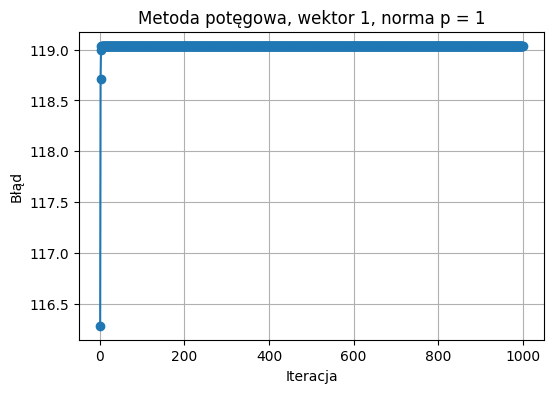

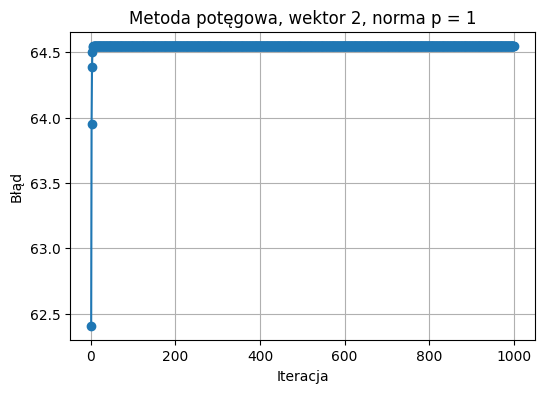

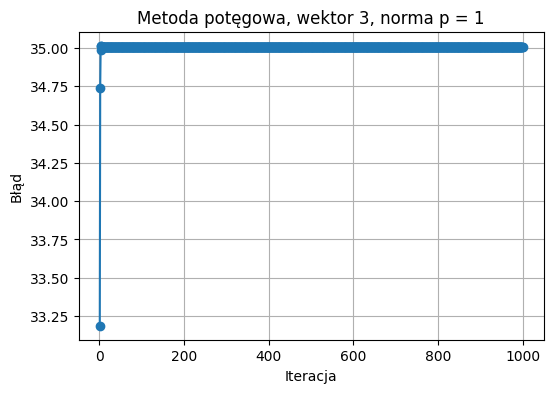

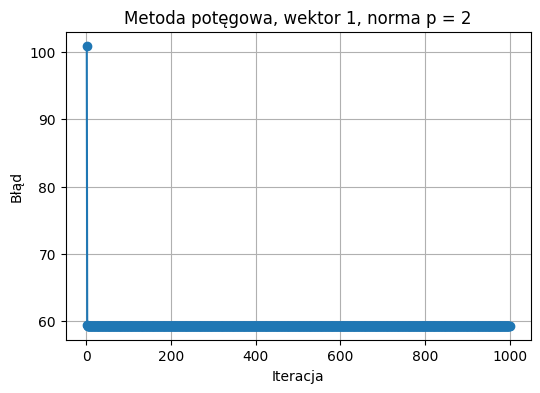

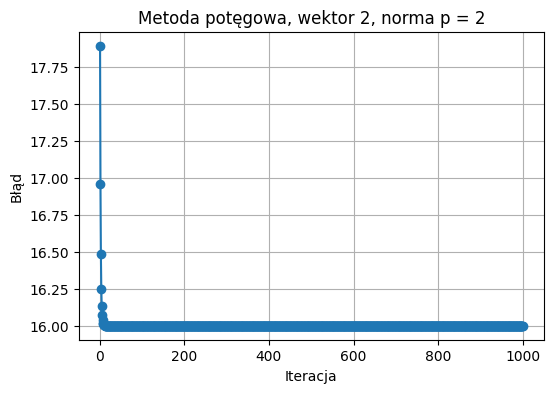

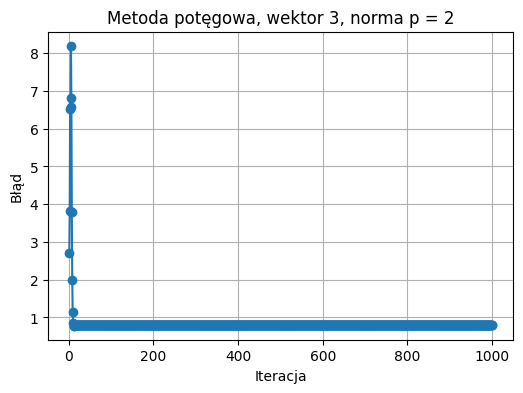

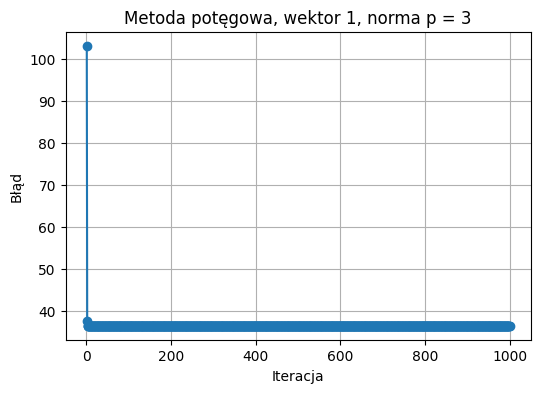

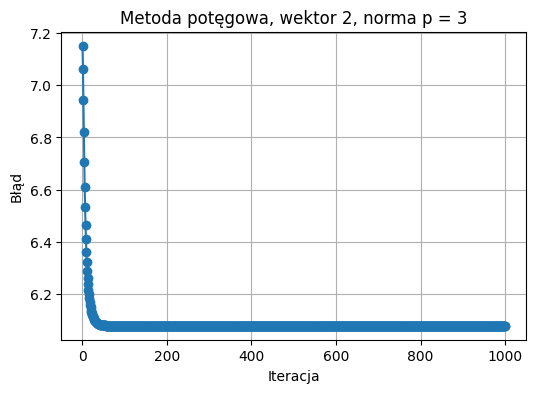

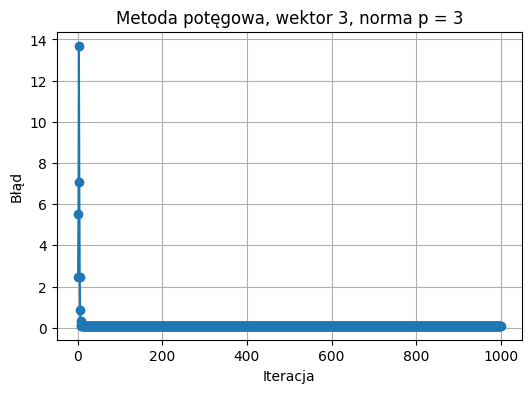

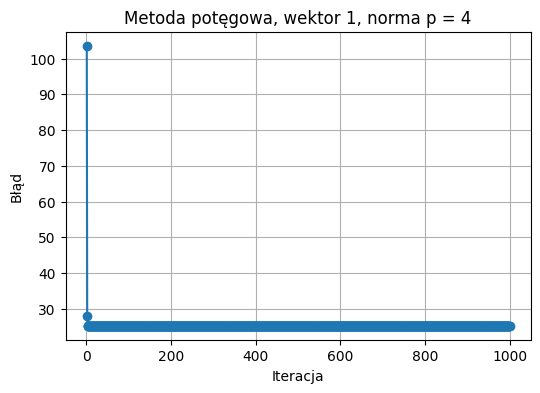

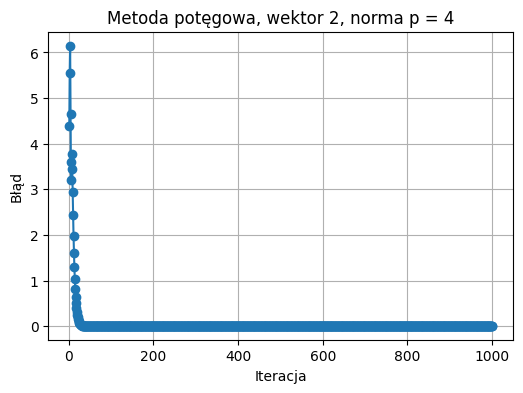

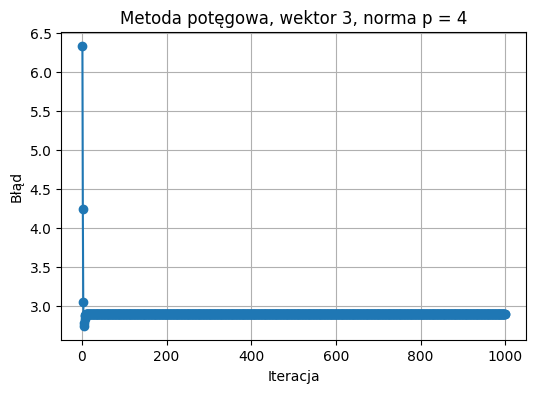

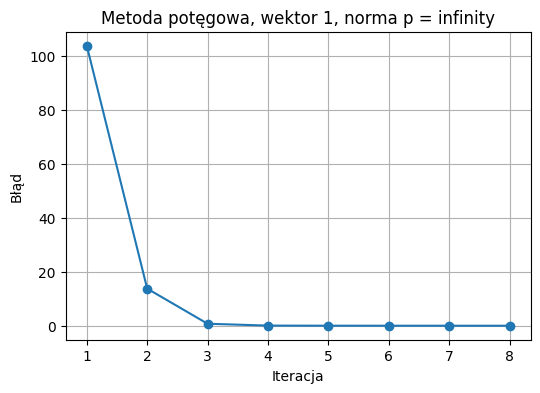

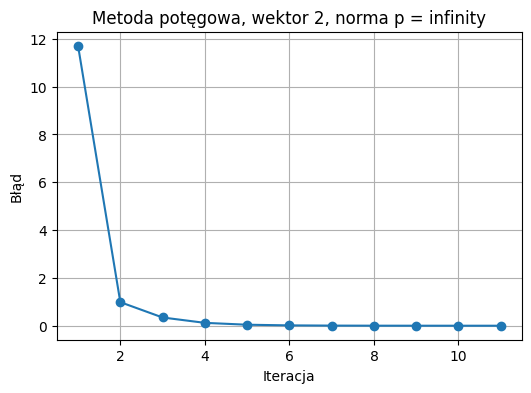

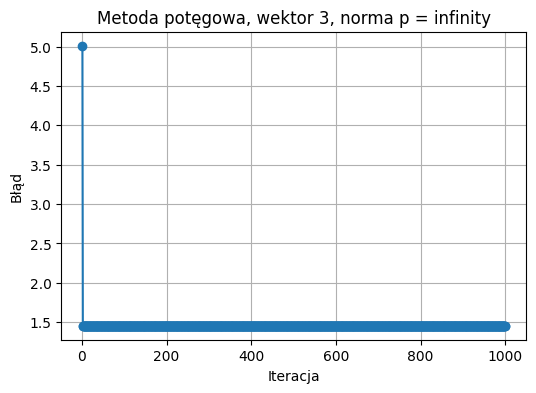

In [28]:
epsilon = 1e-4
B = A @ A.T

for p in norms:
    lambdas, vectors, errors_all = deflation_power_method(
        B,
        epsilon=epsilon,
        p=p,
        seed=20260611
    )
    # for vector_idx, errors in enumerate(errors_all, start=1):
    #     print(f"\nVector {vector_idx}")
    #     print("-" * 40)

    #     for iter_idx, error in enumerate(errors, start=1):
    #         print(f"Iteration {iter_idx:3d}: error = {error:.4e}")
    
    
    for i, errors in enumerate(errors_all):
        plt.figure(figsize=(6, 4))
        plt.plot(range(1, len(errors) + 1), errors, marker="o")
        plt.xlabel("Iteracja")
        plt.ylabel("Błąd")
        plt.title(f"Metoda potęgowa, wektor {i + 1}, norma {norm_names[p]}")
        plt.grid(True)
        plt.show()

In [29]:
for p in norms:
    lambdas, vectors, errors_all = deflation_power_method(
        B,
        epsilon=epsilon,
        p=p,
        seed=20260611
    )

    for i, errors in enumerate(errors_all):
        plt.figure(figsize=(6, 4))
        plt.plot(range(1, len(errors) + 1), errors, marker="o")
        plt.xlabel("Iteracja")
        plt.ylabel("Błąd")
        plt.title(f"Metoda potęgowa, wektor {i + 1}, norma {norm_names[p]}")
        plt.grid(True)

        file_name = f"power_method_norm_{norm_names[p].replace(' ', '_')}_vector_{i + 1}.png"
        plt.savefig(file_name, dpi=300, bbox_inches="tight")
        plt.close()

In [30]:
U_np, s_np, V_np = np.linalg.svd(A)

D_np = np.diag(s_np)

A_numpy_svd = U_np @ D_np @ V_np

print("SVD z biblioteki NumPy:")
print(A_numpy_svd)

SVD z biblioteki NumPy:
[[ 3. -9. -3.]
 [ 7. -7. -5.]
 [ 4. -3.  4.]]


In [31]:
def matrix_as_vector_norm(M, p):
    if p == np.inf:
        return np.linalg.norm(M.ravel(), ord=np.inf)
    return np.linalg.norm(M.ravel(), ord=p)


errors = {}

for p in norms:
    err = matrix_as_vector_norm(A_manual - A_numpy_svd, p)
    errors[p] = err

print("Błędy ||UDV - SVD(A)||_p:")
for p, err in errors.items():
    print(f"p = {p}: {err:.12e}")

Błędy ||UDV - SVD(A)||_p:
p = 1: 2.042810365310e-14
p = 2: 9.294098618032e-15
p = 3: 7.827529282246e-15
p = 4: 7.408228362716e-15
p = inf: 7.105427357601e-15


Ręcznie wyznaczone SVD zostało obliczone na podstawie wartości i wektorów własnych macierzy AA
T
. Wartości osobliwe otrzymano jako pierwiastki z wartości własnych macierzy AA
T
. Następnie macierz V wyznaczono ze wzoru V=A
T
UD
−1
, przy czym w implementacji zastosowano transpozycję tej macierzy, aby rekonstrukcja miała postać UDV, zgodnie z treścią zadania.

Porównanie z wynikiem funkcji np.linalg.svd pokazuje, że błędy rekonstrukcji są bardzo małe, rzędu 10
−14
. Oznacza to, że ręczna metoda obliczania SVD daje wynik zgodny z biblioteką numeryczną z dokładnością do błędów zaokrągleń arytmetyki zmiennoprzecinkowej.

## Komentarz do otrzymanych wyników

W ramach zadania wylosowano macierz $A$ rozmiaru $3 \times 3$, a następnie wyznaczono rozkład SVD na podstawie wartości i wektorów własnych macierzy $AA^T$. Otrzymane macierze $U$, $D$ oraz $V$ pozwalają poprawnie odtworzyć macierz wejściową $A$, co potwierdza rekonstrukcja $UDV$.

Porównanie ręcznie wyznaczonego rozkładu SVD z wynikiem funkcji bibliotecznej `np.linalg.svd` daje bardzo małe błędy, rzędu około $10^{-14}$. Tak małe wartości błędów oznaczają, że otrzymane wyniki są zgodne z wynikiem biblioteki numerycznej z dokładnością do błędów zaokrągleń arytmetyki zmiennoprzecinkowej. Można więc uznać, że część związana z obliczeniem rozkładu SVD została wykonana poprawnie.

W przypadku metody potęgowej analizowano zbieżność dla różnych norm: $p = 1, 2, 3, 4$ oraz dla normy nieskończoność. Dla każdej normy wygenerowano wykresy przedstawiające zmianę błędu w kolejnych iteracjach. Początkowe wartości błędu mogą być stosunkowo duże, nawet rzędu kilkudziesięciu lub kilkuset. Jest to naturalne, ponieważ błąd liczony jest jako norma wyrażenia

$$
\|Az - \lambda z\|_p,
$$

a wartości elementów macierzy $AA^T$ mogą być znacznie większe niż wartości elementów pierwotnej macierzy $A$.

Na wykresach dla norm $p = 1, 2, 3, 4$ można zauważyć, że błąd początkowo maleje, ale następnie stabilizuje się na wartości znacząco większej niż zadane $\varepsilon = 0.0001$. Oznacza to, że dla tych norm algorytm nie osiąga w pełni wymaganego warunku stopu. W takim przypadku zakończenie działania może wynikać raczej z osiągnięcia maksymalnej liczby iteracji niż z faktycznej zbieżności do zadanej dokładności.

Najlepszą zbieżność widać dla normy nieskończoność. W tym przypadku błąd wyraźnie maleje i dla części wektorów osiąga wartości mniejsze od $\varepsilon = 0.0001$. Jest to zgodne z intuicją, ponieważ w zadaniu wartość własna była przybliżana jako

$$
\lambda = \max_i(w_i),
$$

gdzie $w = Az$. Taki sposób wyznaczania wartości własnej jest najbardziej zgodny właśnie z normalizacją w normie nieskończoność, ponieważ wtedy największa współrzędna wektora ma szczególne znaczenie.

Dla pozostałych norm estymator $\lambda = \max_i(w_i)$ nie musi dobrze przybliżać wartości własnej, ponieważ wektor jest normalizowany w innej normie. Z tego powodu błąd $\|Az - \lambda z\|_p$ może nie dążyć do zera, mimo że kierunek wektora w kolejnych iteracjach częściowo się stabilizuje.

Podsumowując, wyniki rozkładu SVD są sensowne i bardzo dokładne numerycznie. Wykresy zbieżności metody potęgowej pokazują natomiast, że zastosowany w treści zadania sposób estymacji wartości własnej przez $\max_i(w_i)$ działa najlepiej dla normy nieskończoność, ale dla norm $p = 1, 2, 3, 4$ może prowadzić do braku pełnej zbieżności błędu do zadanej dokładności. Nie oznacza to błędu w samej analizie, ale wskazuje na ograniczenie przyjętej metody obliczania wartości własnej.